In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import (train_test_split, RandomizedSearchCV)
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, StandardScaler)
from sklearn.impute import SimpleImputer 
from sklearn.pipeline import Pipeline 
from sklearn.tree import (DecisionTreeClassifier, plot_tree)
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report)

In [2]:
df = pd.read_csv('shop_smart_ecommerce.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [4]:
df.shape

(12330, 18)

In [5]:
df.columns.to_list()

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Revenue']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100)
print(pd.concat([missing, missing_pct], keys=['Count', 'Percent%'], axis=1))

                         Count  Percent%
Administrative               0       0.0
Administrative_Duration      0       0.0
Informational                0       0.0
Informational_Duration       0       0.0
ProductRelated               0       0.0
ProductRelated_Duration      0       0.0
BounceRates                  0       0.0
ExitRates                    0       0.0
PageValues                   0       0.0
SpecialDay                   0       0.0
Month                        0       0.0
OperatingSystems             0       0.0
Browser                      0       0.0
Region                       0       0.0
TrafficType                  0       0.0
VisitorType                  0       0.0
Weekend                      0       0.0
Revenue                      0       0.0


In [9]:
df[['Weekend', 'Revenue']] = df[['Weekend', 'Revenue']].astype(int)

In [10]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [12]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [13]:
X.shape

(12330, 17)

In [14]:
num_columns = X.select_dtypes(include='number').columns
cat_columns = X.select_dtypes(include=['object', 'category']).columns

In [15]:
num_columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')

In [16]:
cat_columns

Index(['Month', 'VisitorType'], dtype='object')

In [17]:
for col in cat_columns: 
    print(f" {col} - {df[col].unique()}")

 Month - ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
 VisitorType - ['Returning_Visitor' 'New_Visitor' 'Other']


In [18]:
# Train - test split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [19]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


In [20]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_columns), 
    ('cat', categorical_pipeline, cat_columns)
])


In [21]:
pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [22]:
param_distributions = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": np.arange(2, 11),
    "classifier__min_samples_split": np.arange(2, 11, 2),
    "classifier__min_samples_leaf": np.arange(1, 11)
}

In [23]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,          # number of random combinations to try
    cv=5,               # cross-validation folds
    scoring='f1',       # evaluation metric
    random_state=42,
    n_jobs=-1           # use all CPU cores for parallelism
)

In [24]:
random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': array([ 2, 3..., 8, 9, 10]), 'classifier__min_samples_leaf': array([ 1, 2..., 8, 9, 10]), 'classifier__min_samples_split': array([ 2, 4, 6, 8, 10])}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters: {'classifier__min_samples_split': np.int64(2), 'classifier__min_samples_leaf': np.int64(5), 'classifier__max_depth': np.int64(3), 'classifier__criterion': 'gini'}
Best score: 0.6478927299093006


In [27]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test,y_pred))


Accuracy:
0.8884833738848338


In [28]:
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('classifier',
       

In [29]:
print(confusion_matrix(y_test, y_pred))

[[1951  104]
 [ 171  240]]


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      2055
           1       0.70      0.58      0.64       411

    accuracy                           0.89      2466
   macro avg       0.81      0.77      0.78      2466
weighted avg       0.88      0.89      0.88      2466



In [47]:
# 1. Class balance check (do this BEFORE modeling, ideally)
print(y.value_counts(normalize=True))

# 2. Evaluate the actual best model on TEST set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64
Test F1: 0.6357615894039735
Test Accuracy: 0.8884833738848338
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      2055
           1       0.70      0.58      0.64       411

    accuracy                           0.89      2466
   macro avg       0.81      0.77      0.78      2466
weighted avg       0.88      0.89      0.88      2466



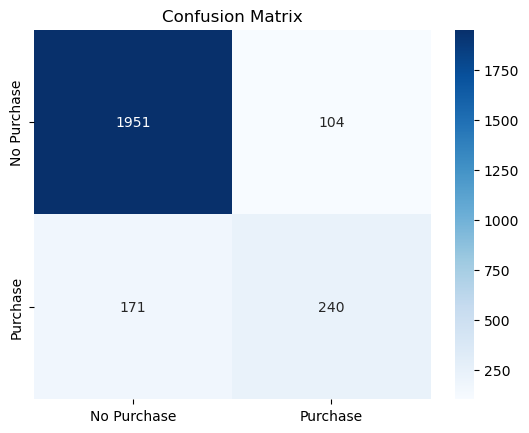

In [48]:
# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title("Confusion Matrix")
plt.show()

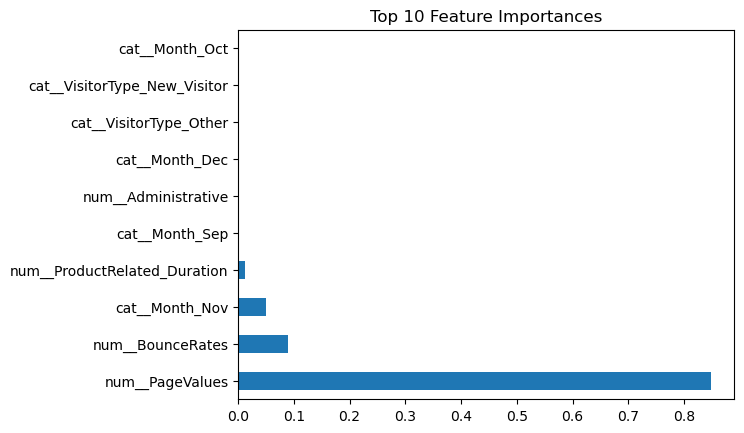

In [49]:
# 4. Feature importance — confirm PageValues dominates
importances = best_model.named_steps['classifier'].feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

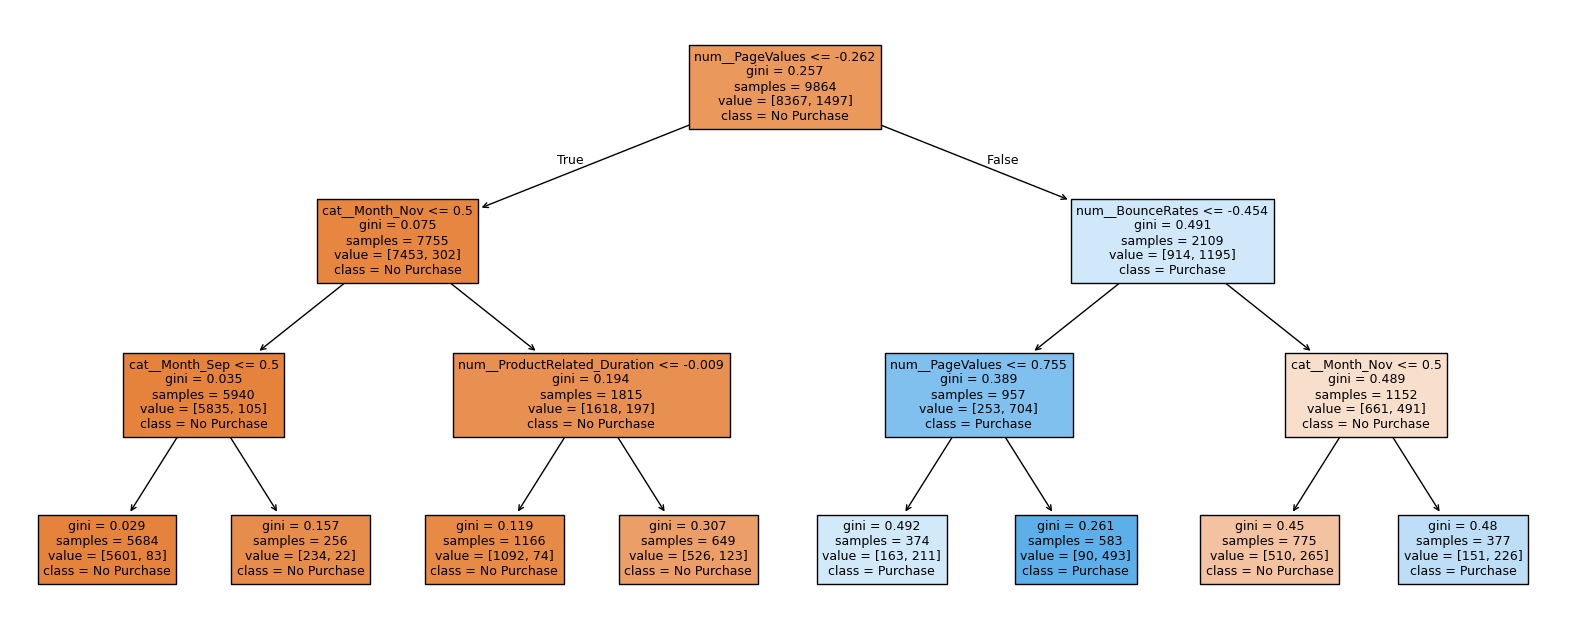

In [50]:
# 5. Visualize the actual tree (it's only max_depth=3, very readable)
plt.figure(figsize=(20, 8))
plot_tree(best_model.named_steps['classifier'], 
          feature_names=feature_names, 
          class_names=['No Purchase', 'Purchase'], 
          filled=True, fontsize=9)
plt.show()

#### Prediction on unseen data 

In [45]:
import pandas as pd

new_data = pd.DataFrame({
    'Administrative':            [0,    2,    0,    5,    1],
    'Administrative_Duration':   [0.0,  45.0, 0.0,  300.0, 20.0],
    'Informational':             [0,    1,    0,    3,    0],
    'Informational_Duration':    [0.0,  30.0, 0.0,  150.0, 0.0],
    'ProductRelated':            [1,    8,    2,    25,   5],
    'ProductRelated_Duration':   [5.0,  200.0, 10.0, 900.0, 80.0],
    'BounceRates':               [0.20, 0.02, 0.50, 0.0,  0.10],
    'ExitRates':                 [0.20, 0.05, 0.40, 0.01, 0.15],
    'PageValues':                [0.0,  15.5, 0.0,  45.2, 0.0],
    'SpecialDay':                [0.0,  0.0,  0.0,  0.0,  0.6],
    'Month':                     ['Feb','Nov','Mar','Nov','May'],
    'OperatingSystems':          [1,    2,    1,    3,    2],
    'Browser':                   [1,    2,    1,    2,    4],
    'Region':                     [1,    3,    4,    1,    9],
    'TrafficType':                [1,    2,    3,    2,    8],
    'VisitorType':                ['New_Visitor','Returning_Visitor','New_Visitor',
                                    'Returning_Visitor','New_Visitor'],
    'Weekend':                    [0,    1,    0,    1,    0]
})

new_data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,5.0,0.20,0.20,0.0,0.0,Feb,1,1,1,1,New_Visitor,0
1,2,45.0,1,30.0,8,200.0,0.02,0.05,15.5,0.0,Nov,2,2,3,2,Returning_Visitor,1
2,0,0.0,0,0.0,2,10.0,0.50,0.40,0.0,0.0,Mar,1,1,4,3,New_Visitor,0
3,5,300.0,3,150.0,25,900.0,0.00,0.01,45.2,0.0,Nov,3,2,1,2,Returning_Visitor,1
4,1,20.0,0,0.0,5,80.0,0.10,0.15,0.0,0.6,May,2,4,9,8,New_Visitor,0


In [46]:
predictions = best_model.predict(new_data)
probabilities = best_model.predict_proba(new_data)[:, 1]

results = new_data[['PageValues', 'ExitRates', 'ProductRelated', 'Month']].copy()
results['Predicted_Revenue'] = predictions
results['Purchase_Probability'] = probabilities.round(3)

results

,PageValues,ExitRates,ProductRelated,Month,Predicted_Revenue,Purchase_Probability
0,0.0,0.20,1,Feb,0,0.015
1,15.5,0.05,8,Nov,1,0.599
2,0.0,0.40,2,Mar,0,0.015
3,45.2,0.01,25,Nov,1,0.846
4,0.0,0.15,5,May,0,0.015
